In [733]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('english')
stop_words.extend(['ipidataservershopeeio','modulehourlyusermartdimus','hoodieingest','schemanameshope','for','to','are', 'a','about','above','across','after','afterwards','again','against','all','almost','alone','along','already','also','although','always', 'am','among','amongst','amoungst','amount','an','and','another','any','anyhow','anyone','anything','anyway','anywhere','are','around', 'as','at','back','be','became','because','become','becomes','becoming','been','before','beforehand','behind','being','below','beside', 'besides','between','beyond','bill','both','bottom','but','by','br','call','can','cannot','cant','co','computer','con','could','couldnt','cry', 'de','describe','detail','do','done','down','due','during','each','eg','eight','either','eleven','else','elsewhere','empty','enough','etc', 'even','ever','every','everyone','everything','everywhere','except','few','fifteen','fify','fill','find','fire','first','five','for','former', 'formerly','forty','found','four','from','front','full','further','get','give','go','had','has','hasnt','have','he','hence','her','here', 'hereafter','hereby','herein','hereupon','hers','herself','him','himself','his','how','however','hundred','i','ie','if','in','inc','indeed', 'interest','into','is','it','its','itself','keep','last','latter','latterly','least','less','ltd','made','many','may','me','meanwhile', 'might','mill','mine','more','moreover','most','mostly','move','much','must','my','myself','name','namely','neither','never','nevertheless', 'next','nine','no','nobody','none','noone','nor','not','nothing','now','nowhere','of','off','often','on','once','one','only','onto','or','other', 'others','otherwise','our','ours','ourselves','out','over','own','part','per','perhaps','please','put','rather','re','same','see','seem','seemed', 'seeming','seems','serious','several','she','should','show','side','since','sincere','six','sixty','so','some','somehow','someone','something', 'sometime','sometimes','somewhere','still','such','system','take','ten','than','that','the','their','them','themselves','then','thence', 'there','thereafter','thereby','therefore','therein','thereupon','these','they','thick','thin','third','this','those','though','three','through', 'throughout','thru','thus','to','together','too','top','toward','towards','twelve','twenty','two','throw','un','under','until','up','upon','us','very', 'via','was','we','well','were','what','whatever','when','whence','whenever','where','whereafter','whereas','whereby','wherein','whereupon', 'wherever','whether','which','while','whither','who','whoever','whole','whom','whose','why','will','with','within','without','would','yet', 'you','your','yours','yourself','yourselves','patternshopeedigitalproductordervndb','didnt','table','patternshopeedigitalproductordermydb', 'patternshopeedigitalproductorderthdb','hoodieingestion','script','vendor','see','httpsnettyiowikireferencecountedobjectshtml','information', 'sgshopeerecommendationworkerlive','mysql_ingestion','hdfs','path','exist','data_vite','project','bootstrap_raw'])


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/chandra.saripaka/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [734]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [735]:
df = pd.read_json("/Users/chandra.saripaka/Downloads/part-00000-a8512aa2-361d-4284-a2fd-caa5c5d62c4c-c000.json", lines=True, encoding='utf-8')

In [736]:
import yake 


data1=df[df['level'].isin(['ERROR'])]
data1['cm'] = data1['class'].str.cat(data1['message'],sep=" ")

data1=data1.drop(columns=['date', 'time', 'filename', 'message', 'class', 'level'])
data1=data1.drop_duplicates()

language = "en"
max_ngram_size = 3
deduplication_thresold = 0.9
deduplication_algo = 'seqm'
windowSize = 1
numOfKeywords = 15

custom_kw_extractor = yake.KeywordExtractor(lan=language, n=max_ngram_size, dedupLim=deduplication_thresold, dedupFunc=deduplication_algo, windowsSize=windowSize, top=numOfKeywords, features=None)

def extract_keywords(text):
        
    post_keywords = custom_kw_extractor.extract_keywords(text)

    sentence_output = ""
    for word, number in post_keywords:
        sentence_output += word + " "

    return sentence_output
    
data1['summary']=data1['cm'].apply(extract_keywords)
    
#data=data1.cm.values.tolist()
#data1=data1.drop(columns=['date', 'time', 'filename', 'message', 'class', 'level'])
#data1=data1.drop_duplicates()
print(data1)

                                                                                                                                                                                                             cm  \
1                                                                                                                                                             CoarseGrainedExecutorBackend RECEIVED SIGNAL TERM   
230     TransportRequestHandler Error sending result RpcResponse{requestId=7779991441153733603, body=NioManagedBuffer{buf=java.nio.HeapByteBuffer[pos=0 lim=81 cap=156]}} to /10.130.161.12:29122; closing c...   
231     TransportRequestHandler Error sending result RpcResponse{requestId=7218885748387219629, body=NioManagedBuffer{buf=java.nio.HeapByteBuffer[pos=0 lim=81 cap=156]}} to /10.130.165.106:40566; closing ...   
232     TransportRequestHandler Error sending result RpcResponse{requestId=9142049755062446761, body=NioManagedBuffer{buf=java.nio.HeapByteBuffer[pos=0 lim=

In [737]:
word='MicroBatchExecution|HoodieIngestion|ContinuousExecution'
data1=data1[~data1['cm'].str.contains(word)]
data_cm=data1.cm.values.tolist()
data_summary=data1.summary.values.tolist()
data1['cm'][:100]
data1.count()

cm         757
summary    757
dtype: int64

In [738]:
def sent_to_words(sentences):
    for sentence in sentences:
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))  # deacc=True removes punctuations

data_words = list(sent_to_words(data_summary))
print(data_words)

[['received', 'signal', 'term', 'received', 'signal', 'signal', 'term', 'received', 'signal', 'received', 'term', 'received', 'signal'], ['error', 'sending', 'error', 'sending', 'result', 'sending', 'result', 'rpcresponse', 'error', 'closing', 'connection', 'requestid', 'body', 'buf', 'pos', 'lim', 'cap', 'error', 'sending', 'result', 'rpcresponse', 'sending', 'result'], ['error', 'sending', 'error', 'sending', 'result', 'sending', 'result', 'rpcresponse', 'error', 'closing', 'connection', 'requestid', 'body', 'buf', 'pos', 'lim', 'cap', 'error', 'sending', 'result', 'rpcresponse', 'sending', 'result'], ['error', 'sending', 'error', 'sending', 'result', 'sending', 'result', 'rpcresponse', 'error', 'closing', 'connection', 'requestid', 'body', 'buf', 'pos', 'lim', 'cap', 'error', 'sending', 'result', 'rpcresponse', 'sending', 'result'], ['error', 'sending', 'error', 'sending', 'result', 'sending', 'result', 'rpcresponse', 'error', 'closing', 'connection', 'requestid', 'body', 'buf', 'po

In [739]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('english')
#stop_words.extend(['ipidataservershopeeio','modulehourlyusermartdimus','hoodieingest','schemanameshope','for','to','are', 'a','about','above','across','after','afterwards','again','against','all','almost','alone','along','already','also','although','always', 'am','among','amongst','amoungst','amount','an','and','another','any','anyhow','anyone','anything','anyway','anywhere','are','around', 'as','at','back','be','became','because','become','becomes','becoming','been','before','beforehand','behind','being','below','beside', 'besides','between','beyond','bill','both','bottom','but','by','br','call','can','cannot','cant','co','computer','con','could','couldnt','cry', 'de','describe','detail','do','done','down','due','during','each','eg','eight','either','eleven','else','elsewhere','empty','enough','etc', 'even','ever','every','everyone','everything','everywhere','except','few','fifteen','fify','fill','find','fire','first','five','for','former', 'formerly','forty','found','four','from','front','full','further','get','give','go','had','has','hasnt','have','he','hence','her','here', 'hereafter','hereby','herein','hereupon','hers','herself','him','himself','his','how','however','hundred','i','ie','if','in','inc','indeed', 'interest','into','is','it','its','itself','keep','last','latter','latterly','least','less','ltd','made','many','may','me','meanwhile', 'might','mill','mine','more','moreover','most','mostly','move','much','must','my','myself','name','namely','neither','never','nevertheless', 'next','nine','no','nobody','none','noone','nor','not','nothing','now','nowhere','of','off','often','on','once','one','only','onto','or','other', 'others','otherwise','our','ours','ourselves','out','over','own','part','per','perhaps','please','put','rather','re','same','see','seem','seemed', 'seeming','seems','serious','several','she','should','show','side','since','sincere','six','sixty','so','some','somehow','someone','something', 'sometime','sometimes','somewhere','still','such','system','take','ten','than','that','the','their','them','themselves','then','thence', 'there','thereafter','thereby','therefore','therein','thereupon','these','they','thick','thin','third','this','those','though','three','through', 'throughout','thru','thus','to','together','too','top','toward','towards','twelve','twenty','two','throw','un','under','until','up','upon','us','very', 'via','was','we','well','were','what','whatever','when','whence','whenever','where','whereafter','whereas','whereby','wherein','whereupon', 'wherever','whether','which','while','whither','who','whoever','whole','whom','whose','why','will','with','within','without','would','yet', 'you','your','yours','yourself','yourselves','patternshopeedigitalproductordervndb','didnt','table','patternshopeedigitalproductordermydb', 'patternshopeedigitalproductorderthdb','hoodieingestion','script','vendor','see','httpsnettyiowikireferencecountedobjectshtml','information', 'sgshopeerecommendationworkerlive','mysql_ingestion','hdfs','path','exist','data_vite','project','bootstrap_raw'])


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/chandra.saripaka/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [740]:
# Build the bigram and trigram models
bigram = gensim.models.Phrases(data_words, min_count=5, threshold=100) # higher threshold fewer phrases.
trigram = gensim.models.Phrases(bigram[data_words], threshold=100)  

# Faster way to get a sentence clubbed as a trigram/bigram
bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)

# See trigram example
print(trigram_mod[bigram_mod[data_words[0]]])

['received', 'signal', 'term', 'received', 'signal', 'signal', 'term', 'received', 'signal', 'received', 'term', 'received', 'signal']


In [741]:
# Define functions for stopwords, bigrams, trigrams and lemmatization
def remove_stopwords(texts):
    return [word for word in gensim.utils.simple_preprocess(str(texts), deacc=True) if word not in stop_words]

def make_bigrams(texts):
    return [bigram_mod[doc] for doc in texts]

def make_trigrams(texts):
    return [trigram_mod[bigram_mod[doc]] for doc in texts]

def lemmatization(texts, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
    """https://spacy.io/api/annotation"""
    texts_out = []
    for sent in texts:
        #print(sent)
        doc = nlp(" ".join(sent)) 
        texts_out.append([token.lemma_ for token in doc if token.pos_ in allowed_postags])
    return texts_out

In [742]:
import re
import spacy
#nlp = spacy.load('en', disable=['ner', 'parser'])



def spacy_process(text):
    #print(text)
    doc = nlp(text)
    #print(doc)
    
            
    # Remove Stop Words
    data_words_nostops = remove_stopwords(doc)
    print(data_words_nostops)

    # Do lemmatization keeping only noun, adj, vb, adv
    #data_lemmatized = lemmatization(data_words_nostops)

    #print(" ")
    #print("Remove stopword & punctuation: ")
    print(data_words_nostops)
    return " ".join(data_words_nostops)

#Removes non-alphabetic characters:
def text_strip(column):
    for row in column:
        
        row=re.sub("(\\t)", ' ', str(row)).lower() #remove escape charecters
        row=re.sub("(\\r)", ' ', str(row)).lower() 
        row=re.sub("(\\n)", ' ', str(row)).lower()
        row=re.sub("(.*.idata-server.shopee.io/[0-9\.]*:[0-9]*)",'HostIPPort',str(row)).lower()
        row=re.sub("(/[0-9\.]*:[0-9]*)",'IPPort',str(row)).lower()
        row=re.sub("(.*.idata-server.shopee.io:[0-9]*)",'HostPort',str(row)).lower()
        row=re.sub("(.*.idata-server.shopee.io):",'Host',str(row)).lower()
        row=re.sub("(container container_[a-z0-9_]*)",'CONTAINERWITHID',str(row)).lower()
        row=re.sub("(container_[a-z0-9_]*)",'CONTAINERID',str(row)).lower()
        row=re.sub("(container on host: .*.idata-server\.shopee\.(io|io.))",'CONTAINERONHOST',str(row)).lower()
        row=re.sub("(timed out after [0-9]* ms)",'TIMEDOUTAFTERMS',str(row)).lower()
        row=re.sub("(quiet for [0-9]* ms)",'QUIETFORMS',str(row)).lower()
        row=re.sub("(executor [0-9]* ms)",'EXECUTORID',str(row)).lower()
        row=re.sub("(stage [0-9\.]*)",'STAGEID',str(row)).lower()
        row=re.sub("(task [0-9\.]*)",'TASKID',str(row)).lower()
        row=re.sub("(failed [0-9\.]* times)",'FAILNTIMES',str(row)).lower()
        #row = spacy_process(str(row))
        #row=re.sub("(__+)", ' ', str(row)).lower()   #remove _ if it occors more than one time consecutively
        row=re.sub("(--+)", '', str(row)).lower()   #remove - if it occors more than one time consecutively
        row=re.sub("(~~+)", ' ', str(row)).lower()   #remove ~ if it occors more than one time consecutively
        row=re.sub("(\+\++)", ' ', str(row)).lower()   #remove + if it occors more than one time consecutively
        row=re.sub("(\.)", '_', str(row)).lower()   #remove . if it occors more than one time consecutively
        
        row=re.sub("(\s+.\s+)", ' ', str(row)).lower() #remove any single charecters hanging between 2 spaces

        row = re.sub("(\s+)",' ',str(row)).lower() #remove multiple spaces
        
        #Should always be last
        row=re.sub("(\s+.\s+)", ' ', str(row)).lower() #remove any single charecters hanging between 2 spaces
        
        yield row

In [743]:
brief_cleaning1 = text_strip(data1['cm'])
brief_cleaning2 = text_strip(data1['summary'])

In [744]:
from time import time
import spacy
nlp = spacy.load('en', disable=['parser']) # disabling Named Entity Recognition for speed

#Taking advantage of spaCy .pipe() method to speed-up the cleaning process:
#If data loss seems to be happening(i.e len(text) = 50 instead of 75 etc etc) in this cell , decrease the batch_size parametre 

t = time()

#Batch the data points into 5000 and run on all cores for faster preprocessing
text = [str(doc) for doc in brief_cleaning1]

#Takes 7-8 mins
print('Time to clean up everything: {} mins'.format(round((time() - t) / 60, 2)))
print(text)

Time to clean up everything: 0.0 mins
['coarsegrainedexecutorbackend received signal term', 'transportrequesthandler error sending result rpcresponse{requestid=7779991441153733603, body=niomanagedbuffer{buf=java_nio_heapbytebuffer[pos=0 lim=81 cap=156]}} to ipport; closing connection', 'transportrequesthandler error sending result rpcresponse{requestid=7218885748387219629, body=niomanagedbuffer{buf=java_nio_heapbytebuffer[pos=0 lim=81 cap=156]}} to ipport; closing connection', 'transportrequesthandler error sending result rpcresponse{requestid=9142049755062446761, body=niomanagedbuffer{buf=java_nio_heapbytebuffer[pos=0 lim=81 cap=156]}} to ipport; closing connection', 'transportrequesthandler error sending result rpcresponse{requestid=5073223262981081518, body=niomanagedbuffer{buf=java_nio_heapbytebuffer[pos=0 lim=81 cap=156]}} to ipport; closing connection', 'executor exception in taskid in stageid (tid 426)', 'executor exception in taskid in stageid (tid 416)', 'executor exception in

**Seq2Seq LSTM Modelling**
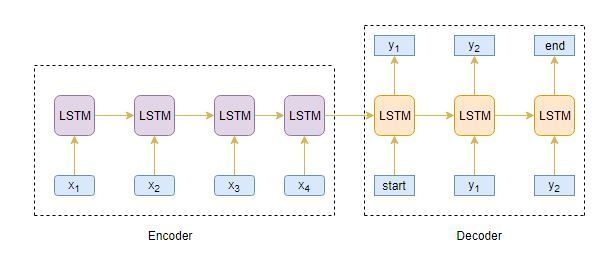

> **Perform Data Cleansing**

In [745]:
#Taking advantage of spaCy .pipe() method to speed-up the cleaning process:


t = time()

#Batch the data points into 5000 and run on all cores for faster preprocessing
summary = ['_START_ '+ str(doc) + ' _END_' for doc in brief_cleaning2]

#Takes 7-8 mins
print('Time to clean up everything: {} mins'.format(round((time() - t) / 60, 2)))
#print(summary)

Time to clean up everything: 0.01 mins


In [746]:
text[0]
len(text)

757

In [747]:
summary[0]
len(summary)

757

In [748]:
#data1['cleaned_text'] = pd.Series(text)
#data1['cleaned_summary'] = pd.Series(summary)
data1['cleaned_text'] = text
data1['cleaned_summary'] = summary

In [749]:
text_count = []
summary_count = []

In [750]:
for sent in data1['cleaned_text']:
    text_count.append(len(str(sent).split()))
for sent in data1['cleaned_summary']:
    summary_count.append(len(str(sent).split()))

In [751]:
graph_df= pd.DataFrame()
graph_df['text']=text_count
graph_df['summary']=summary_count

In [752]:
from matplotlib import pyplot

graph_df.hist(bins = 5)
pyplot.show()

ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.

In [753]:
#Check how much % of summary have 0-15 words
cnt=0
for i in data1['cleaned_summary']:
    if(str(i) != 'nan' and len(i.split())<=15):
        cnt=cnt+1
print(cnt/len(data1['cleaned_summary']))

0.22721268163804492


In [754]:
#Check how much % of text have 0-70 words
cnt=0
for i in data1['cleaned_text']:
    if(str(i) != 'nan' and len(i.split())<=100):
        cnt=cnt+1
print(cnt/len(data1['cleaned_text']))

1.0


In [755]:
#Model to summarize the text between 0-15 words for Summary and 0-100 words for Text
max_text_len=200
max_summary_len=50

In [756]:
#Select the Summaries and Text between max len defined above

cleaned_text =np.array(data1['cleaned_text'])
cleaned_summary=np.array(data1['cleaned_summary'])

short_text=[]
short_summary=[]

for i in range(len(cleaned_text)):
    if(len(cleaned_summary[i].split())<=max_summary_len and len(cleaned_text[i].split())<=max_text_len):
        short_text.append(cleaned_text[i])
        short_summary.append(cleaned_summary[i])
        
data2=pd.DataFrame({'text':short_text,'summary':short_summary})

In [758]:
#Add sostok and eostok at 
data2['summary'] = data2['summary'].apply(lambda x : 'sostok '+ x + ' eostok')


**SEQ2SEQ MODEL BUILDING **

Split the data to TRAIN and VALIDATION sets

In [760]:
from sklearn.model_selection import train_test_split
x_tr,x_val,y_tr,y_val=train_test_split(np.array(data2['text']),np.array(data2['summary']),test_size=0.1,random_state=0,shuffle=True)

In [761]:
#Lets tokenize the text to get the vocab count , you can use Spacy here also

from keras.preprocessing.text import Tokenizer 
from keras.preprocessing.sequence import pad_sequences

#prepare a tokenizer for reviews on training data
x_tokenizer = Tokenizer() 
x_tokenizer.fit_on_texts(list(x_tr))

**RARE WORD ANALYSIS FOR X i.e 'text'**
* tot_cnt gives the size of vocabulary (which means every unique words in the text)

* cnt gives me the no. of rare words whose count falls below threshold

* tot_cnt - cnt gives me the top most common words

In [762]:
thresh=4

cnt=0
tot_cnt=0
freq=0
tot_freq=0

for key,value in x_tokenizer.word_counts.items():
    tot_cnt=tot_cnt+1
    tot_freq=tot_freq+value
    if(value<thresh):
        cnt=cnt+1
        freq=freq+value
    
print("% of rare words in vocabulary:",(cnt/tot_cnt)*100)
print("Total Coverage of rare words:",(freq/tot_freq)*100)

% of rare words in vocabulary: 70.40498442367601
Total Coverage of rare words: 7.588723886232067


In [763]:

#prepare a tokenizer for reviews on training data
x_tokenizer = Tokenizer(num_words=tot_cnt-cnt) 
x_tokenizer.fit_on_texts(list(x_tr))

#convert text sequences into integer sequences (i.e one-hot encodeing all the words)
x_tr_seq    =   x_tokenizer.texts_to_sequences(x_tr) 
x_val_seq   =   x_tokenizer.texts_to_sequences(x_val)

#padding zero upto maximum length
x_tr    =   pad_sequences(x_tr_seq,  maxlen=max_text_len, padding='post')
x_val   =   pad_sequences(x_val_seq, maxlen=max_text_len, padding='post')

#size of vocabulary ( +1 for padding token)
x_voc   =  x_tokenizer.num_words + 1

print("Size of vocabulary in X = {}".format(x_voc))

Size of vocabulary in X = 191


**RARE WORD ANALYSIS FOR Y i.e 'summary'**
* tot_cnt gives the size of vocabulary (which means every unique words in the text)

* cnt gives me the no. of rare words whose count falls below threshold

* tot_cnt - cnt gives me the top most common words

In [764]:
#prepare a tokenizer for reviews on training data
y_tokenizer = Tokenizer()   
y_tokenizer.fit_on_texts(list(y_tr))

In [765]:
thresh=6

cnt=0
tot_cnt=0
freq=0
tot_freq=0

for key,value in y_tokenizer.word_counts.items():
    tot_cnt=tot_cnt+1
    tot_freq=tot_freq+value
    if(value<thresh):
        cnt=cnt+1
        freq=freq+value
    
print("% of rare words in vocabulary:",(cnt/tot_cnt)*100)
print("Total Coverage of rare words:",(freq/tot_freq)*100)

% of rare words in vocabulary: 44.15584415584416
Total Coverage of rare words: 1.6383773510714987


In [766]:
#prepare a tokenizer for reviews on training data
y_tokenizer = Tokenizer(num_words=tot_cnt-cnt) 
y_tokenizer.fit_on_texts(list(y_tr))

#convert text sequences into integer sequences (i.e one hot encode the text in Y)
y_tr_seq    =   y_tokenizer.texts_to_sequences(y_tr) 
y_val_seq   =   y_tokenizer.texts_to_sequences(y_val) 

#padding zero upto maximum length
y_tr    =   pad_sequences(y_tr_seq, maxlen=max_summary_len, padding='post')
y_val   =   pad_sequences(y_val_seq, maxlen=max_summary_len, padding='post')

#size of vocabulary
y_voc  =   y_tokenizer.num_words +1
print("Size of vocabulary in Y = {}".format(y_voc))

Size of vocabulary in Y = 130


We will now remove "Summary" i.e Y (both train and val) which has only _START_ and _END_

In [767]:
ind=[]
for i in range(len(y_tr)):
    cnt=0
    for j in y_tr[i]:
        if j!=0:
            cnt=cnt+1
    if(cnt==2):
        ind.append(i)

y_tr=np.delete(y_tr,ind, axis=0)
x_tr=np.delete(x_tr,ind, axis=0)

In [768]:
ind=[]
for i in range(len(y_val)):
    cnt=0
    for j in y_val[i]:
        if j!=0:
            cnt=cnt+1
    if(cnt==2):
        ind.append(i)

y_val=np.delete(y_val,ind, axis=0)
x_val=np.delete(x_val,ind, axis=0)

In [769]:
from keras import backend as K 
import gensim
from numpy import *
import numpy as np
import pandas as pd 
import re
from bs4 import BeautifulSoup
from keras.preprocessing.text import Tokenizer 
from keras.preprocessing.sequence import pad_sequences
from nltk.corpus import stopwords
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Concatenate, TimeDistributed
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import warnings
pd.set_option("display.max_colwidth", 200)
warnings.filterwarnings("ignore")

print("Size of vocabulary from the w2v model = {}".format(x_voc))

K.clear_session()

latent_dim = 300
embedding_dim=200

# Encoder
encoder_inputs = Input(shape=(max_text_len,))

#embedding layer
enc_emb =  Embedding(x_voc, embedding_dim,trainable=True)(encoder_inputs)

#encoder lstm 1
encoder_lstm1 = LSTM(latent_dim,return_sequences=True,return_state=True,dropout=0.4,recurrent_dropout=0.4)
encoder_output1, state_h1, state_c1 = encoder_lstm1(enc_emb)

#encoder lstm 2
encoder_lstm2 = LSTM(latent_dim,return_sequences=True,return_state=True,dropout=0.4,recurrent_dropout=0.4)
encoder_output2, state_h2, state_c2 = encoder_lstm2(encoder_output1)

#encoder lstm 3
encoder_lstm3=LSTM(latent_dim, return_state=True, return_sequences=True,dropout=0.4,recurrent_dropout=0.4)
encoder_outputs, state_h, state_c= encoder_lstm3(encoder_output2)

# Set up the decoder, using `encoder_states` as initial state.
decoder_inputs = Input(shape=(None,))

#embedding layer
dec_emb_layer = Embedding(y_voc, embedding_dim,trainable=True)
dec_emb = dec_emb_layer(decoder_inputs)

decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True,dropout=0.4,recurrent_dropout=0.2)
decoder_outputs,decoder_fwd_state, decoder_back_state = decoder_lstm(dec_emb,initial_state=[state_h, state_c])

#dense layer
decoder_dense =  TimeDistributed(Dense(y_voc, activation='softmax'))
decoder_outputs = decoder_dense(decoder_outputs)

# Define the model 
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.summary()


Size of vocabulary from the w2v model = 191
Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 200)]        0                                            
__________________________________________________________________________________________________
embedding (Embedding)           (None, 200, 200)     38200       input_1[0][0]                    
__________________________________________________________________________________________________
lstm (LSTM)                     [(None, 200, 300), ( 601200      embedding[0][0]                  
__________________________________________________________________________________________________
input_2 (InputLayer)            [(None, None)]       0                                            
__________________________________________________

In [770]:
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy')


In [771]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1,patience=2)


**Start fitting the model with the data**

In [772]:
history=model.fit([x_tr,y_tr[:,:-1]], y_tr.reshape(y_tr.shape[0],y_tr.shape[1], 1)[:,1:] ,epochs=50,callbacks=[es],batch_size=128, validation_data=([x_val,y_val[:,:-1]], y_val.reshape(y_val.shape[0],y_val.shape[1], 1)[:,1:]))


Train on 681 samples, validate on 76 samples
Epoch 1/50
681/681 [==============================] - 61s 90ms/sample - loss: 3.5003 - val_loss: 2.1970
Epoch 2/50
681/681 [==============================] - 31s 46ms/sample - loss: 1.9335 - val_loss: 1.7269
Epoch 3/50
681/681 [==============================] - 34s 50ms/sample - loss: 1.7859 - val_loss: 1.6073
Epoch 4/50
681/681 [==============================] - 33s 49ms/sample - loss: 1.9112 - val_loss: 1.5401
Epoch 5/50
681/681 [==============================] - 35s 51ms/sample - loss: 1.5896 - val_loss: 1.4989
Epoch 6/50
681/681 [==============================] - 35s 51ms/sample - loss: 1.5454 - val_loss: 1.3330
Epoch 7/50
681/681 [==============================] - 35s 51ms/sample - loss: 1.3903 - val_loss: 1.3055
Epoch 8/50
681/681 [==============================] - 34s 50ms/sample - loss: 1.3849 - val_loss: 1.1931
Epoch 9/50
681/681 [==============================] - 34s 50ms/sample - loss: 1.2604 - val_loss: 1.0844
Epoch 10/50
681/681

**Visualize the model learning**

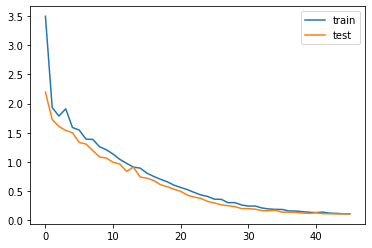

In [773]:
from matplotlib import pyplot
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

**Next, let’s build the dictionary to convert the index to word for target and source vocabulary:**

In [774]:
reverse_target_word_index=y_tokenizer.index_word
reverse_source_word_index=x_tokenizer.index_word
target_word_index=y_tokenizer.word_index

In [775]:
# Encode the input sequence to get the feature vector
encoder_model = Model(inputs=encoder_inputs,outputs=[encoder_outputs, state_h, state_c])

# Decoder setup
# Below tensors will hold the states of the previous time step
decoder_state_input_h = Input(shape=(latent_dim,))
decoder_state_input_c = Input(shape=(latent_dim,))
decoder_hidden_state_input = Input(shape=(max_text_len,latent_dim))

# Get the embeddings of the decoder sequence
dec_emb2= dec_emb_layer(decoder_inputs) 
# To predict the next word in the sequence, set the initial states to the states from the previous time step
decoder_outputs2, state_h2, state_c2 = decoder_lstm(dec_emb2, initial_state=[decoder_state_input_h, decoder_state_input_c])

# A dense softmax layer to generate prob dist. over the target vocabulary
decoder_outputs2 = decoder_dense(decoder_outputs2) 

# Final decoder model
decoder_model = Model(
    [decoder_inputs] + [decoder_hidden_state_input,decoder_state_input_h, decoder_state_input_c],
    [decoder_outputs2] + [state_h2, state_c2])

**We are defining a function below which is the implementation of the inference process**

In [776]:
def decode_sequence(input_seq):
    # Encode the input as state vectors.
    e_out, e_h, e_c = encoder_model.predict(input_seq)
    
    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1,1))
    
    # Populate the first word of target sequence with the start word.
    target_seq[0, 0] = target_word_index['sostok']

    stop_condition = False
    decoded_sentence = ''
    while not stop_condition:
      
        output_tokens, h, c = decoder_model.predict([target_seq] + [e_out, e_h, e_c])

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_token = reverse_target_word_index[sampled_token_index]
        
        if(sampled_token!='eostok'):
            decoded_sentence += ' '+sampled_token

        # Exit condition: either hit max length or find stop word.
        if (sampled_token == 'eostok'  or len(decoded_sentence.split()) >= (max_summary_len-1)):
            stop_condition = True

        # Update the target sequence (of length 1).
        target_seq = np.zeros((1,1))
        target_seq[0, 0] = sampled_token_index

        # Update internal states
        e_h, e_c = h, c

    return decoded_sentence

**Let us define the functions to convert an integer sequence to a word sequence for summary as well as the reviews:**


In [777]:
def seq2summary(input_seq):
    newString=''
    for i in input_seq:
        if((i!=0 and i!=target_word_index['sostok']) and i!=target_word_index['eostok']):
            newString=newString+reverse_target_word_index[i]+' '
    return newString

def seq2text(input_seq):
    newString=''
    for i in input_seq:
        if(i!=0):
            newString=newString+reverse_source_word_index[i]+' '
    return newString

**Run the model over the data to see the results**

In [ ]:
for i in range(1,681):
    print("Review:",seq2text(x_tr[i]))
    print("Original summary:",seq2summary(y_tr[i]))
    print("Predicted summary:",decode_sequence(x_tr[i].reshape(1,max_text_len)))
    print("\n")

Review: datawritingsparktaskidaborting commit for partition taskid attempt 0 stageid 
Original summary: start datawritingsparktaskidaborting commit datawritingsparktaskidaborting aborting commit commit for partition taskidattempt stageidaborting datawritingsparktaskidpartition commit end 
Predicted summary:  start yarnclusterscheduler lost executor executor heartbeat timed yarnclusterscheduler lost lost executor executor heartbeat heartbeat timed executor lost yarnclusterscheduler heartbeat timed end


Review: hostport executor heartbeat timedoutafterms 
Original summary: start yarnclusterscheduler lost executor executor heartbeat timed yarnclusterscheduler lost lost executor executor heartbeat heartbeat timed executor lost yarnclusterscheduler heartbeat timed end 
Predicted summary:  start yarnclusterscheduler lost executor executor heartbeat timed yarnclusterscheduler lost lost executor executor heartbeat heartbeat timed executor lost yarnclusterscheduler heartbeat timed end


Review